In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

### Newton's Method

Newton's method build a sequence of values $\{x_n\}$ via functional iteration that converges to the root of a function $f$. Let that root be called $x_\infty$ and let $x_n$ be the current estimate. By the mean value theorem, we know there exists some $z$ such that

$$f(x_n) = f^\prime(z)(x_n-x_\infty),

$$

where $z$ is somewhere between $x_n$ and $x_\infty$. Rearranging terms, we can write

$$x_\infty = x_n-\frac{f(x_n)}{f^\prime(z)}$$

Obviously, we do not know $x_\infty$ or $z$, so we can replace them with our next iterate $x_{n+1}$ and our current iterate $x_n$, giving us the Newton update formula,

$$x_{n+1} = x_n - \frac{f(x_n)}{f^\prime(x_n)}.

$$

We will discuss Newton's method more in the later section on general optimization, as it is a core method for minimizing functions.

#### Proof of Newton's Method

Newton's method can be written as a functional iteration that converges to a fixed point. Let $f$ be a function that is twice continuously differentiable and suppose there exists a $x_\infty$ such that $f(x_\infty) = 0$ and $f^\prime(x_\infty)\ne 0$. Then there exists a $\delta$ such that for any $x_0\in(x_\infty-\delta, x_\infty+\delta)$, the sequence

$$x_n = g(x_{n-1}) = x_{n-1} - \frac{f(x_{n-1})}{f^\prime(x_{n-1})}$$

converges to $x_\infty$.

Note that

$$\begin{eqnarray*}
g^\prime(x)
&  = &
1-\frac{f^\prime(x)f^\prime(x)-f(x)f^{\prime\prime}(x)}{[f^\prime(x)]^2}\\
&  = &
\frac{f(x)f^{\prime\prime}(x)}{[f^\prime(x)]^2}
\end{eqnarray*}$$

Therefore, $g^\prime(x_\infty) = 0$ because we assume $f(x_\infty) = 0$ and $f^\prime(x_\infty)\ne 0$. Further we know $g^\prime$ is continuous because we assumed $f$ was twice continuously differentiable.

Therefore, given $K < 1$, there exists $\delta > 0$ such that for all $x\in(x_\infty-\delta, x_\infty+\delta)$, we have $|g^\prime(x)|< K$. For any $a, b\in(x_\infty-\delta, x_\infty+\delta)$ we can also write

$$\begin{eqnarray*}
|g(a)-g(b)|
&  \leq &
|g^\prime(c)||a-b|\\
&  \leq &
K|a-b|
\end{eqnarray*}$$

In the interval of $x_\infty\pm\delta$ we have that $g$ is a shrinking map. Therefore, there exists a unique fixed point $x_\infty$ such that $g(x_\infty)=x_\infty$. This value $x_\infty$ is a root of $f$.

#### Convergence Rate of Newton's Method

Although proof of Newton's method's convergence to a root can be done using the Shrinking Lemma, the convergence rate of Newton's method is considerably faster than the linear rate of generic shrinking maps. This fast convergence is obtained via the additional assumptions we make about the smoothness of the function $f$.

Suppose again that $f$ is twice continuously differentiable and that there exists $x_\infty$ such that $f(x_\infty) = 0$. Given some small $\varepsilon > 0$, we can approximate $f$ around $x_\infty$ with

$$\begin{eqnarray*}
f(x_\infty+\varepsilon)
&  = &
f(x_\infty) + \varepsilon f^\prime(x_\infty)+\frac{\varepsilon^2}{2}f^{\prime\prime}(x_\infty) + O(\varepsilon^2)\\
&  = &
0 + \varepsilon f^\prime(x_\infty)+\frac{\varepsilon^2}{2}f^{\prime\prime}(x_\infty) + O(\varepsilon^2)
\end{eqnarray*}$$

Additionally, we can approximate $f^\prime$ with

$$f^\prime(x_\infty+\varepsilon) = f^\prime(x_\infty) + \varepsilon f^{\prime\prime}(x_\infty) + O(\varepsilon)

$$

Recall that Newton's method generates the sequence

$$x_{n+1} = x_n - \frac{f(x_n)}{f^\prime(x_n)}.

$$

Using the time-honored method of adding and subtracting, we can write this as

$$x_{n+1} - x_\infty = x_n - x_\infty - \frac{f(x_n)}{f^\prime(x_n)}.

$$

If we let $\varepsilon_{n+1}=x_{n+1} - x_\infty$ and $\varepsilon_n=x_n - x_\infty$, then we can rewrite the above as

$$\varepsilon_{n+1} = \varepsilon_n - \frac{f(x_n)}{f^\prime(x_n)}$$

Further adding and subtracting (i.e. $x_n = x_\infty + \varepsilon_n$) gives us

$$\varepsilon_{n+1} = \varepsilon_n - \frac{f(x_\infty+\varepsilon_n)}{f^\prime(x_\infty+\varepsilon_n)}$$

From here, we can use the approximations written out earlier to give us

$$\begin{eqnarray*}
\varepsilon_{n+1}
&  \approx &
\varepsilon_n - \frac{\varepsilon_n f^\prime(x_\infty) + \frac{\varepsilon_n^2}{2}f^{\prime\prime}(x_\infty)}{f^\prime(x_\infty)+\varepsilon_n f^{\prime\prime}(x_\infty)}\\
&  = &
\varepsilon_n^2\left(\frac{\frac{1}{2}f^{\prime\prime}(x_\infty)}{f^\prime(x_\infty) + \varepsilon_n f^{\prime\prime}(x_\infty)}\right)
\end{eqnarray*}$$

Dividing by $\varepsilon_n^2$ on both sides gives us

$$\frac{\varepsilon_{n+1}}{\varepsilon_n^2} \approx \frac{\frac{1}{2}f^{\prime\prime}(x_\infty)}{f^\prime(x_\infty) + \varepsilon_n f^{\prime\prime}(x_\infty)}$$

As $\varepsilon_n\downarrow 0$, we can say that there exists some $M<\infty$ such that

$$\frac{|\varepsilon_{n+1}|}{|\varepsilon_n|^2} \leq M

$$

as $n\rightarrow\infty$, which is the definition of quadratic convergence. Of course, for this to work we need that $f^{\prime\prime}(x_\infty)<\infty$ and that $f^\prime(x_\infty)\ne 0$.

In summary, Newton's method is very fast in the neighborhood of the root and furthermore has a direct multivariate generalization (unlike the bisection method). However, the need to evaluate $f^\prime$ at each iteration requires more computation (and more assumptions about the smoothness of $f$). Additionally, Newton's method can, in a sense, be "too fast" in that there is no guarantee that each iteration of Newton's method is an improvement (i.e. is closer to the root). In certain cases, Newton's method can swing wildly out of control and diverge. Newton's method is only guaranteed to converge in the neighborhood of the root; the exact size of that neighborhood is usually not known.

#### Newton's Method for Maximum Likelihood Estimation

In many statistical modeling applications, we have a likelihood function $L$ that is induced by a probability distribution that we assume generated the data. This likelihood is typically parameterized by a vector $\theta$ and maximizing $L(\theta)$ provides us with the *maximum likelihood estimate* (MLE), or $\hat{\theta}$. In practice, it makes more sense to maximize the log-likehood function, or $\ell(\theta)$, which in many common applications is equivalent to solving the *score equations* $\ell^\prime(\theta) = 0$ for $\theta$.

Newton's method can be applied to generate a sequence that converges to the MLE $\hat{\theta}$. If we assume $\theta$ is a $k\times 1$ vector, we can iterate

$$\theta_{n+1} = \theta_n - \ell^{\prime\prime}(\theta_n)^{-1}\ell^\prime(\theta_n)

$$

where $\ell^{\prime\prime}$ is the Hessian of the log-likelihood function.

Note that the formula above computes an inverse of a $k\times k$ matrix, which should serve as an immediate warning sign that this is **not** how the algorithm should be implemented. In practice, it may make more sense to solve the system of equations

$$[\ell^{\prime\prime}(\theta_n)]\theta_{n+1} = [\ell^{\prime\prime}(\theta_n)]\theta_n-\ell^\prime(\theta_n).

$$

rather than invert $\ell^{\prime\prime}(\theta_n)$ directly at every iteration.

However, it may make sense to invert $\ell^{\prime\prime}(\theta_n)$ at the very end of the algorithm to obtain the *observed information matrix* $-\ell^{\prime\prime}(\hat{\theta})$. This observed information matrix can be used to obtain asymptotic standard errors for $\hat{\theta}$ for making inference about $\theta$.

##### Example: Estimating a Poisson Mean

Suppose we observe data $x_1, x_2, \dots, x_n\stackrel{iid}{\sim}\text{Poisson}(\mu)$ and we would like to estimate $\mu$ via maximum likelihood. The log-likelihood induced by the Poisson model is

$$\ell(\mu) = \sum_{i=1}^n x_i\log\mu - \mu = n\bar{x}\log\mu - n\mu

$$

The score function is

$$\ell^\prime(\mu) = \frac{n\bar{x}}{\mu}-n

$$

It is clear that setting $\ell^\prime(\mu)$ to zero and solving for $\mu$ gives us that $\hat{\mu}=\bar{x}$. However, we can visualizing $\ell^\prime(\mu)$ and see how the Newton iteration would work in this simple scenario.


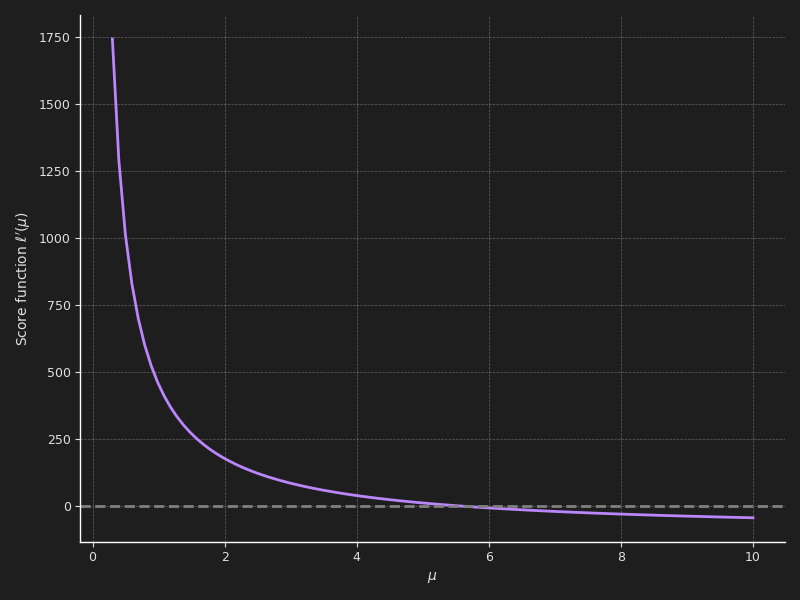

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2017-8-9)
x = np.random.poisson(5, 100)
xbar = np.mean(x)
n = len(x)

def score(mu):
    return n * xbar / mu - n

x_vals = np.linspace(0.3, 10, 100)
y_vals = [score(mu) for mu in x_vals]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_vals, y_vals)
ax.axhline(y=0, linestyle='--', color='gray')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r"Score function $\ell'(\mu)$")
plt.tight_layout()

### Newton Iteration for Poisson Mean

For the Newton iteration, we need the second derivative:

$$\ell''(\mu) = -\frac{n\bar{x}}{\mu^2}$$

So the Newton iteration becomes:

$$\mu_{n+1} = \mu_n - \left[-\frac{n\bar{x}}{\mu_n^2}\right]^{-1}\left(\frac{n\bar{x}}{\mu_n}-n\right) = 2\mu_n - \frac{\mu_n^2}{\bar{x}}$$


Starting value: 10
True MLE: 5.530000

Newton iteration results:
  Iteration 0: μ = 10.0000000000
  Iteration 1: μ = 1.9168173599
  Iteration 2: μ = 3.1692244501
  Iteration 3: μ = 4.5221769987
  Iteration 4: μ = 5.3463278116
  Iteration 5: μ = 5.5238995528
  Iteration 6: μ = 5.5299932703
  Iteration 7: μ = 5.5300000000


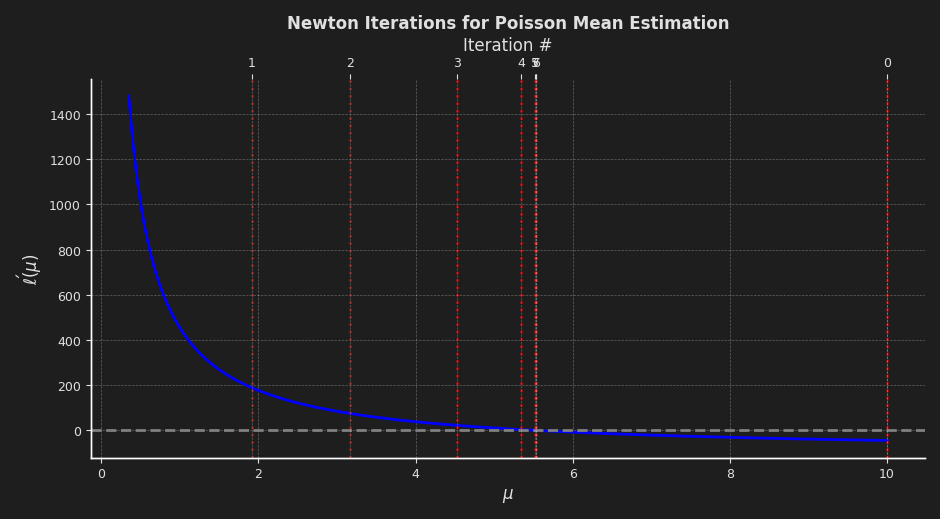

In [3]:
def newton_step(mu):
    """Single Newton iteration for Poisson mean estimation."""
    return 2 * mu - mu**2 / xbar

# Execute multiple Newton iterations starting from mu_0 = 10
mu_0 = 10
iterations = 7
mu_values = [mu_0]

for i in range(iterations):
    mu_values.append(newton_step(mu_values[-1]))

# Plot with vertical lines showing iterations
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
x_vals = np.linspace(0.35, 10, 200)
y_vals = [score(mu) for mu in x_vals]

ax.plot(x_vals, y_vals, 'b-', linewidth=2, label='Score function')
ax.axhline(y=0, linestyle='--', color='gray')

# Add vertical lines for iterations
for mu_val in mu_values:
    ax.axvline(x=mu_val, linestyle=':', color='red', alpha=0.5)

# Add x-axis labels for iteration numbers
ax.set_xlabel(r'$\mu$', fontsize=12)
ax.set_ylabel(r'$\ell\'(\mu)$', fontsize=12)
ax.set_title('Newton Iterations for Poisson Mean Estimation')

# Create secondary x-axis for iteration numbers
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(mu_values)
ax2.set_xticklabels([str(i) for i in range(len(mu_values))])
ax2.set_xlabel('Iteration #', fontsize=12)

plt.tight_layout()

# Print convergence
print(f"Starting value: {mu_0}")
print(f"True MLE: {xbar:.6f}")
print(f"\nNewton iteration results:")
for i, mu_val in enumerate(mu_values):
    print(f"  Iteration {i}: μ = {mu_val:.10f}")